In [4]:
import pandas as pd

# Load the datasets from the specified paths
df_all_unique = pd.read_csv("../dataanalysis/all_data_unique.tsv", sep="\t")

aa_1_to_3 = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
} # Mapping von 1-Buchstaben zu 3-Buchstaben Aminosäuren

# Berechnen wie oft eine Aminosäure in der jeweiligen CDRs vorkommt und in Prozent
def calculate_aa_distribution(df, column):
    aa_counts = df[column].dropna().apply(lambda x: pd.Series(list(x))).stack().value_counts() # wie oft jede AS vorkommt
    total_count = aa_counts.sum() # Totale Anzahl der Aminosäuren
    aa_distribution = (aa_counts / total_count * 100).round(2) # konvertiere in Prozent und runde auf 2 Dezimalstellen
    return aa_distribution 


import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_aa_distribution(corona, influenza, human, region_label="CDR_H3"): #definition der Funktion um die Verteilung der Aminosäuren zu plotten
    """
    Plots the grouped amino acid distribution for three datasets.
    Args:
        corona (pd.Series): Amino acid distribution for Corona.
        influenza (pd.Series): Amino acid distribution for Influenza.
        human (pd.Series): Amino acid distribution for Human.
        region_label (str): Label for the region being analyzed.
    """

    aa_order = list(aa_1_to_3.keys()) # aa_order ist eine Liste der Aminosäuren in der Reihenfolge von aa_1_to_3.keys()
    labels_3 = [aa_1_to_3[aa] for aa in aa_order] # labels_3 ist eine Liste der Aminosäuren in der 3-Buchstaben Abkürzung

    # Reindex all distributions for consistent order and fill missing with 0
    corona = corona.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Corona
    influenza = influenza.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Influenza
    human = human.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Human

    x = np.arange(len(aa_order)) # Positionen der Balken auf der x-Achse
    width = 0.25 # Breite der Balken

    # Generieren  des Balkendiagramms
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, corona.values, width, label='Corona', color='pink')
    plt.bar(x,         influenza.values, width, label='Influenza', color='mediumpurple')
    plt.bar(x + width, human.values, width, label='Human', color='skyblue')

    plt.xticks(ticks=x, labels=labels_3, rotation=45)
    plt.ylabel("Häufigkeit (%)")
    plt.xlabel("Aminosäure")
    plt.title(f"Aminosäureverteilung in {region_label}")
    plt.ylim(0, 25)  
    plt.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()




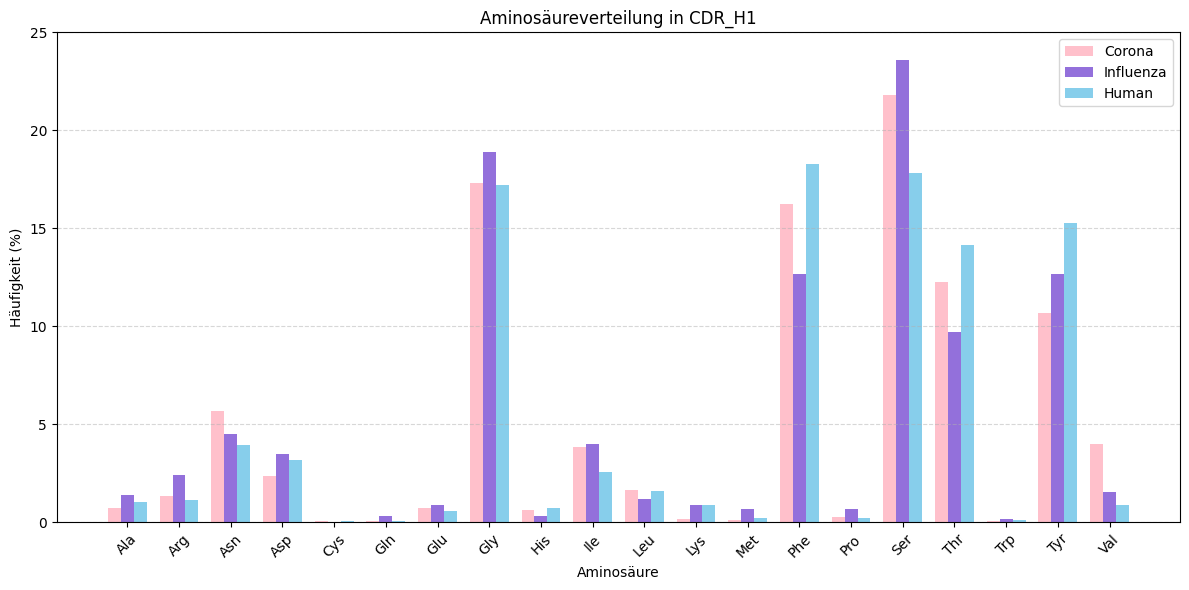

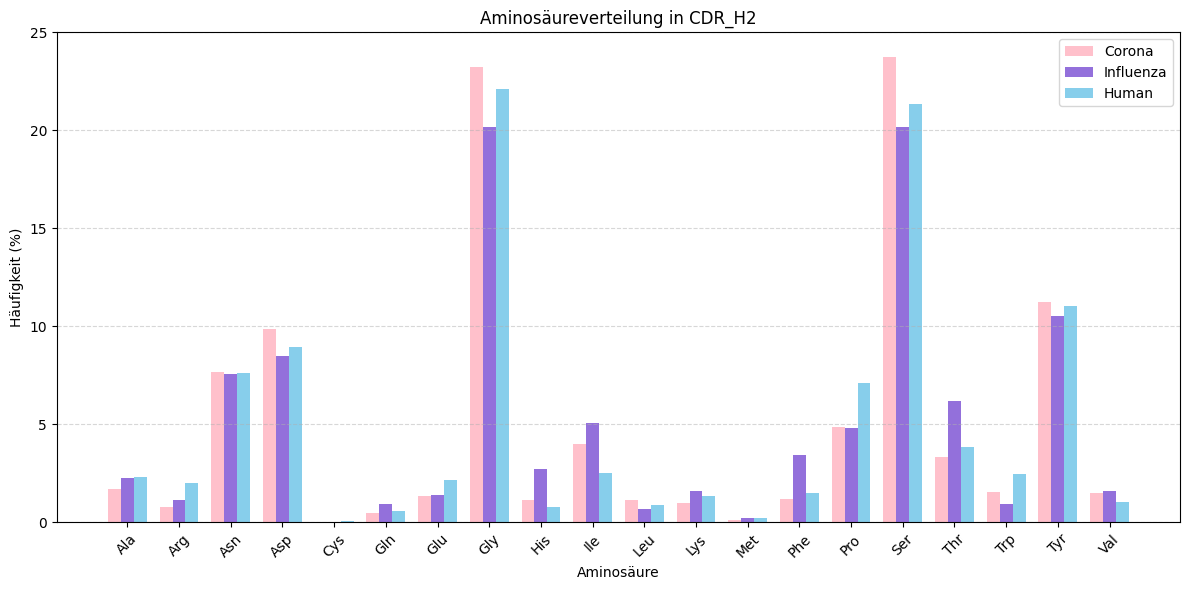

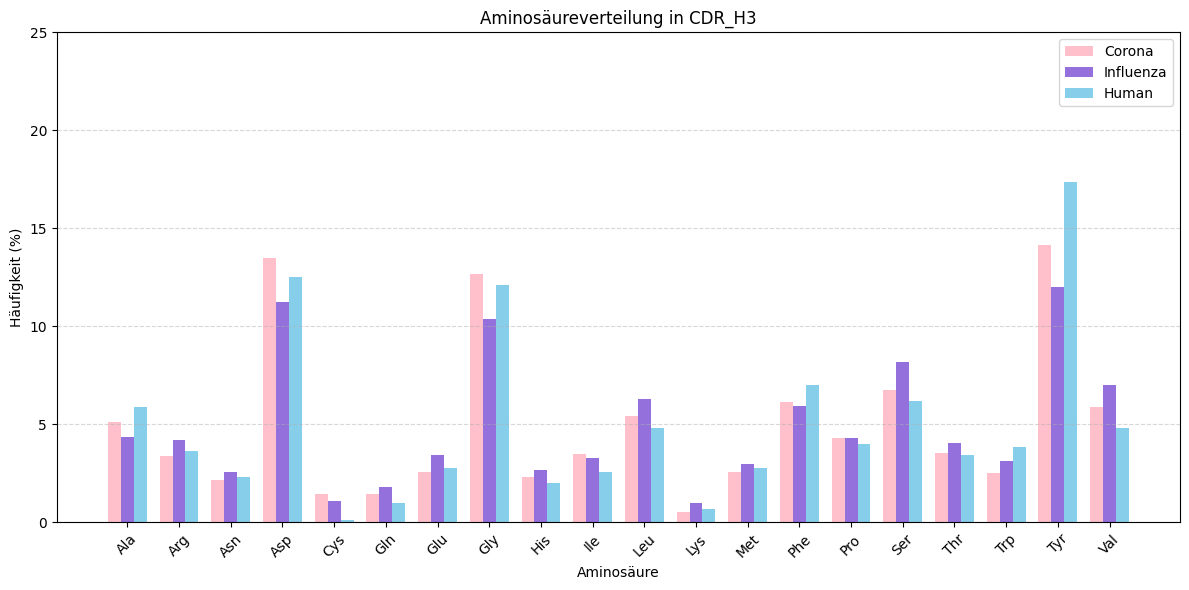

In [7]:
for region in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    # Filtern nach Quelle und Berechnung pro Region
    dist_corona = calculate_aa_distribution(df_all_unique[df_all_unique["source"] == "sars_cov2"], region)
    dist_influenza = calculate_aa_distribution(df_all_unique[df_all_unique["source"] == "influenza"], region)
    dist_human = calculate_aa_distribution(df_all_unique[df_all_unique["source"] == "human"], region)

    # Gruppiertes Balkendiagramm
    plot_grouped_aa_distribution(dist_corona, dist_influenza, dist_human, region_label=region)
